In [1]:
import pandas as pd
import numpy as np

## İçeri aktaralım dosyayı ve daha sonra ilk 5 satırını oku

In [2]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Dosyanın kaça kaçlık olduğunu bulalım 

In [4]:
df.shape

(768, 9)

## Veri setine istatiksel bi şekilde bakış yapalım

In [6]:
df.info()               ## Değişkenler düzenli, hepsi sayısal veri olarak gözüküyor bu tam istdiğim

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Dataframe'nin ortalamaları,sapmaları ve çeyreklik değerlerini alalım

In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Eksik verileri saplama

In [12]:
missing_data = df.isnull()
missing_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False


In [14]:
## Eksik verileri saptamak için for döngüsü kurabiliriz her blok için ayrı ayrı görebilirz.

for column in missing_data.columns.values.tolist():
    print(column)
    print(missing_data[column].value_counts())
    print("")

## en basit sayma mantığı 

print(df.isnull().sum())

Pregnancies
Pregnancies
False    768
Name: count, dtype: int64

Glucose
Glucose
False    768
Name: count, dtype: int64

BloodPressure
BloodPressure
False    768
Name: count, dtype: int64

SkinThickness
SkinThickness
False    768
Name: count, dtype: int64

Insulin
Insulin
False    768
Name: count, dtype: int64

BMI
BMI
False    768
Name: count, dtype: int64

DiabetesPedigreeFunction
DiabetesPedigreeFunction
False    768
Name: count, dtype: int64

Age
Age
False    768
Name: count, dtype: int64

Outcome
Outcome
False    768
Name: count, dtype: int64

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## Veri türünü kontrol etmek için = dtypes
## Veri Türünü değiştirmek için  = astype() = burada veriler temiz gerek yok

In [15]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

# Visualization (Seaborn ve matplotlib)

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

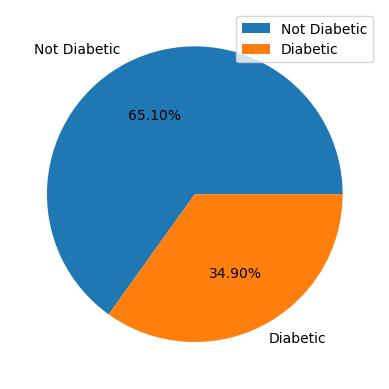

In [ ]:
# 1. Grafik üzerindeki dilimlerin isimlerini sırasıyla belirliyoruz
labels = 'Not Diabetic', 'Diabetic'

# 2. Pasta grafiğini çizdiriyoruz:
# - df['Outcome'].value_counts(): Diyabet sütunundaki 0 ve 1'lerin (hasta olan/olmayan) adetlerini sayıp dilim boyutlarını ayarlar
# - labels=labels: Dilimlerin isimlerini yukarıda tanımladığımız metinler yapar
# - autopct='%0.02f%%': Dilimlerin üzerine yüzde değerlerini iki basamaklı formatta yazdırır
plt.pie(df['Outcome'].value_counts(), labels=labels, autopct='%0.02f%%')

# 3. Grafiğin sağ üst köşesine hangi rengin ne anlama geldiğini gösteren kutucuğu (lejantı) ekler
plt.legend()

# 4. Hazırlanan grafiği ekranda görsel olarak gösterir
plt.show()